# 🛒 Análise de Gastos - LigaMagic

Análise detalhada das compras realizadas pelo marketplace da LigaMagic, com foco em gastos por loja.

In [1]:
import re
import warnings
from datetime import datetime
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from bs4 import BeautifulSoup

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
})

print("✅ Bibliotecas carregadas com sucesso.")


✅ Bibliotecas carregadas com sucesso.


## 1. Parsing do HTML

In [2]:
with open("compras.html", "r", encoding="utf-8") as f:
    html = f.read()

soup = BeautifulSoup(html, "html.parser")

# Each order lives inside a div.boxshadow.conteudo.box-interna
order_blocks = soup.select("div.boxshadow.conteudo.box-interna.box-margin-t")
print(f"Total de blocos de pedidos encontrados: {len(order_blocks)}")


Total de blocos de pedidos encontrados: 115


## 2. Extração dos Dados

In [3]:
def parse_value(value_str):
    """Converts 'R$ 1.822,50' to float 1822.50"""
    if not value_str:
        return 0.0
    cleaned = value_str.replace("R$", "").strip()
    cleaned = cleaned.replace(".", "").replace(",", ".")
    try:
        return float(cleaned)
    except ValueError:
        return 0.0

def parse_date(date_str):
    """Extracts a datetime from '(2 anos atrás - 18/03/2024 21:11)'"""
    if not date_str:
        return None
    match = re.search(r"(\d{2}/\d{2}/\d{4})\s+(\d{2}:\d{2})", date_str)
    if match:
        try:
            return datetime.strptime(f"{match.group(1)} {match.group(2)}", "%d/%m/%Y %H:%M")
        except ValueError:
            return None
    return None

records = []

for block in order_blocks:
    # Order number
    order_el = block.select_one("font.titleorder")
    order_id = order_el.get_text(strip=True) if order_el else None

    # Date
    date_el = block.select_one("font.titledate")
    date_text = date_el.get_text(strip=True) if date_el else None
    order_date = parse_date(date_text)

    # Each block can have multiple stores (infovendas rows)
    info_rows = block.select("div.infovendas")

    for row in info_rows:
        # Store name
        store_el = row.select_one("div.venda-store label.title")
        if store_el:
            # Get text but exclude child elements like <a> and <img>
            store_name = store_el.find(string=True, recursive=False)
            if store_name:
                store_name = store_name.strip()
            else:
                # fallback: get all text
                store_name = store_el.get_text(strip=True)
        else:
            store_name = "Desconhecido"

        # Value
        value_el = row.select_one("div.venda-value label.aux")
        value_text = value_el.get_text(strip=True) if value_el else "0"
        value = parse_value(value_text)

        # Status
        status_el = row.select_one("div.venda-status label.aux")
        status = status_el.get_text(strip=True) if status_el else "Desconhecido"

        # Shipping method
        track_els = row.select("div.venda-track label.aux")
        shipping_method = track_els[0].get_text(strip=True) if len(track_els) > 0 else ""
        tracking_code = track_els[1].get_text(strip=True) if len(track_els) > 1 else ""

        records.append({
            "pedido": order_id,
            "data": order_date,
            "loja": store_name,
            "valor": value,
            "status": status,
            "envio": shipping_method if shipping_method else "N/A",
            "rastreio": tracking_code if tracking_code and tracking_code != "-" else None,
        })

df_all = pd.DataFrame(records)
print(f"Total de registros (linhas de pedido) extraídos: {len(df_all)}")
df_all.head(10)


Total de registros (linhas de pedido) extraídos: 115


,pedido,data,loja,valor,status,envio,rastreio
0,#10642144,2026-04-11 11:45:00,Magic Raiz,811.03,Enviado,SEDEX,OY808168936BR
1,#10275456,2026-02-22 14:34:00,Monster Games Cards,813.80,Enviado,- SEDEX -,OY652439465BR
2,#10167559,2026-02-07 12:52:00,FREITAS TCG,911.24,Enviado,Frete Grátis - Sul e Sudeste,AN588926930BR
3,#10167542,2026-02-07 12:50:00,Monster Games Cards,1058.34,Enviado,- SEDEX -,AD091242738BR
4,#10014252,2026-01-17 12:37:00,Magicdomain,369.32,Enviado,RETIRADAS NA LOJA DOMAIN RIO PRETO,AB946122708BR
5,#9922894,2026-01-04 14:20:00,City Class Games,1103.74,Enviado,Sedex,OY517779204BR
6,#9893952,2025-12-27 22:34:00,Monster Games Cards,1163.70,Enviado,- SEDEX -,AB914265339BR
7,#9862573,2025-12-21 07:13:00,Loja do Toguro,1797.98,Retirado no Balcão,RETIRAR NA LOJA(NECESSARIO SE ATENTAR AO PRAZO).,NaN
8,#8649351,2025-06-07 23:01:00,Monster Games Cards,1359.84,Enviado,- SEDEX -,AC703107858BR
9,#8585643,2025-05-28 22:13:00,Gold House,337.33,Enviado,SEDEX,AC666890683BR


## 3. Visão Geral dos Dados

In [4]:
print("=== Status dos Pedidos ===")
print(df_all['status'].value_counts().to_string())
print(f"\nTotal bruto (todos os status): R$ {df_all['valor'].sum():,.2f}")
print(f"Total cancelado:                R$ {df_all[df_all['status'] == 'Cancelado']['valor'].sum():,.2f}")

# Filter out cancelled orders for the main analysis
df = df_all[df_all['status'] != 'Cancelado'].copy()
print(f"\n✅ Removidos pedidos cancelados. Registros restantes: {len(df)}")
print(f"Total gasto efetivo: R$ {df['valor'].sum():,.2f}")


=== Status dos Pedidos ===
status
Enviado                     73
Retirado no Balcão          16
Entregue/Enviado            14
** Retirado no Balcão **     6
Cancelado                    4
Pedidos Finalizados          1
Finalizado                   1

Total bruto (todos os status): R$ 69,080.03
Total cancelado:                R$ 2,743.69

✅ Removidos pedidos cancelados. Registros restantes: 111
Total gasto efetivo: R$ 66,336.34


## 4. Gasto por Loja (Top 15)

In [5]:
store_stats = df.groupby("loja").agg(
    total_gasto=("valor", "sum"),
    num_pedidos=("valor", "count"),
    ticket_medio=("valor", "mean"),
    maior_pedido=("valor", "max"),
).sort_values("total_gasto", ascending=False)

store_stats["ticket_medio"] = store_stats["ticket_medio"].round(2)
store_stats["total_gasto"] = store_stats["total_gasto"].round(2)

print(f"Total de lojas distintas: {len(store_stats)}")
store_stats.head(15)


Total de lojas distintas: 27


,total_gasto,num_pedidos,ticket_medio,maior_pedido
loja,,,,
SpellCast,8845.73,4,2211.43,3192.72
Monster Games Cards,8424.73,9,936.08,1485.12
UGCardShop,6845.15,7,977.88,2360.25
Barão Geek House,6054.13,14,432.44,1316.67
Loja do Toguro,5948.51,9,660.95,1797.98
Prime MTG,3919.10,4,979.78,2141.39
Gold House,3827.04,8,478.38,1210.47
MMGeekGames,3542.54,1,3542.54,3542.54
City Class Games,2720.33,5,544.07,1103.74


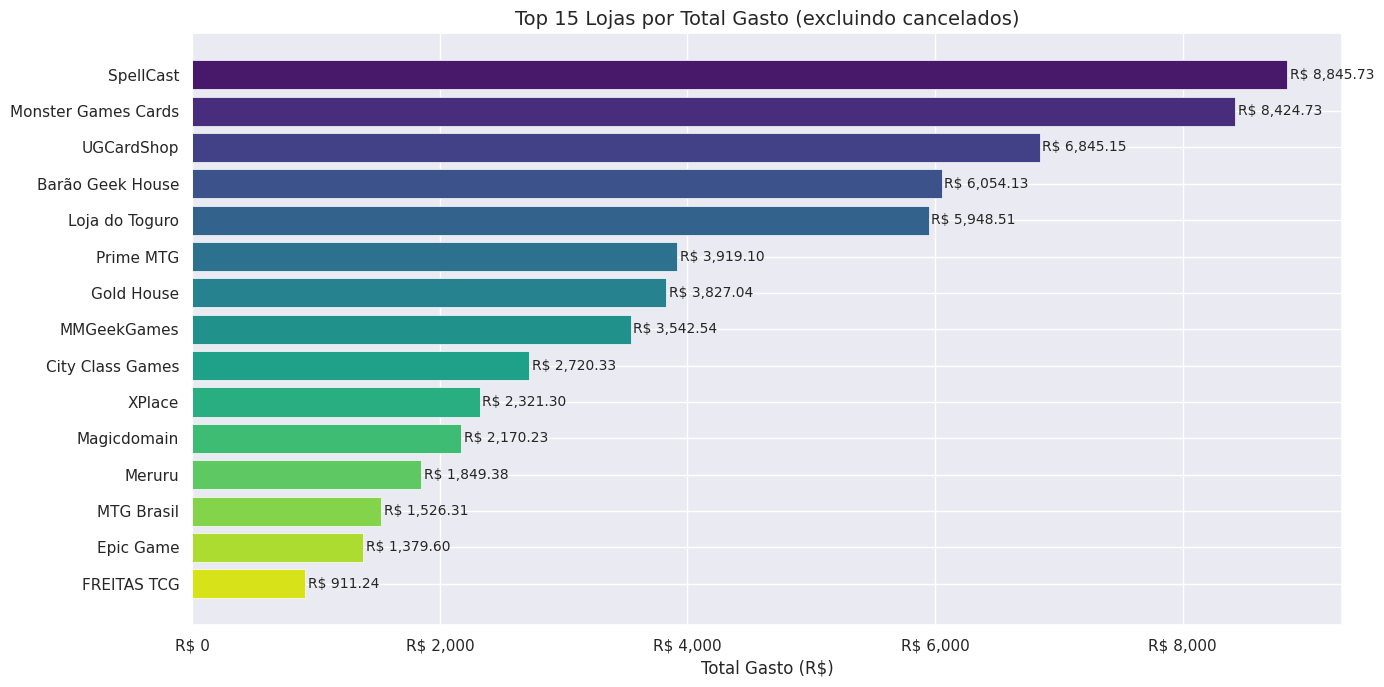

In [6]:
top_n = 15
top_stores = store_stats.head(top_n)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    top_stores.index[::-1],
    top_stores["total_gasto"].values[::-1],
    color=sns.color_palette("viridis", top_n)[::-1],
    edgecolor="white",
    linewidth=0.5,
)

for bar, val in zip(bars, top_stores["total_gasto"].values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f"R$ {val:,.2f}", va='center', fontsize=10)

ax.set_xlabel("Total Gasto (R$)")
ax.set_title(f"Top {top_n} Lojas por Total Gasto (excluindo cancelados)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.tight_layout()
plt.show()


## 5. Número de Pedidos por Loja (Top 15)

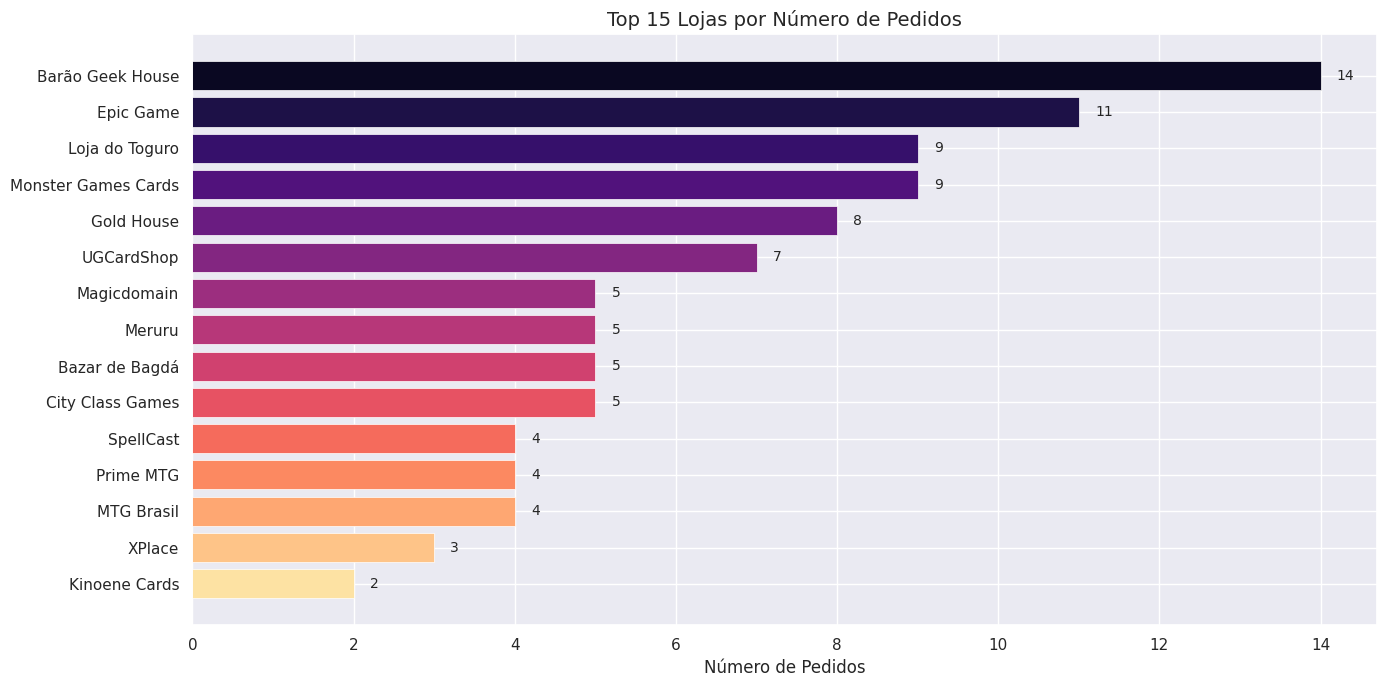

In [7]:
top_by_orders = store_stats.sort_values("num_pedidos", ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    top_by_orders.index[::-1],
    top_by_orders["num_pedidos"].values[::-1],
    color=sns.color_palette("magma", top_n)[::-1],
    edgecolor="white",
    linewidth=0.5,
)

for bar, val in zip(bars, top_by_orders["num_pedidos"].values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{int(val)}", va='center', fontsize=10)

ax.set_xlabel("Número de Pedidos")
ax.set_title(f"Top {top_n} Lojas por Número de Pedidos")
plt.tight_layout()
plt.show()


## 6. Ticket Médio por Loja (Top 15, mínimo 2 pedidos)

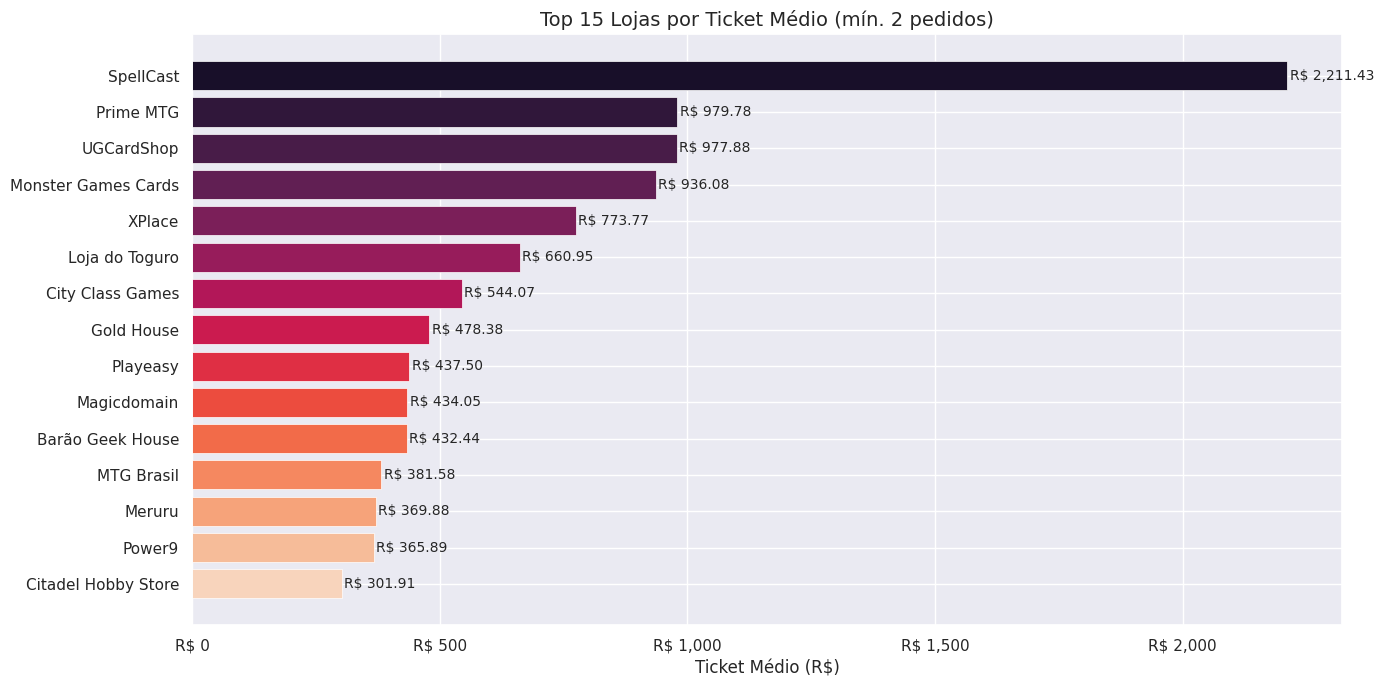

In [8]:
# Filter stores with at least 2 orders for meaningful average
stores_min2 = store_stats[store_stats["num_pedidos"] >= 2].sort_values("ticket_medio", ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    stores_min2.index[::-1],
    stores_min2["ticket_medio"].values[::-1],
    color=sns.color_palette("rocket", top_n)[::-1],
    edgecolor="white",
    linewidth=0.5,
)

for bar, val in zip(bars, stores_min2["ticket_medio"].values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"R$ {val:,.2f}", va='center', fontsize=10)

ax.set_xlabel("Ticket Médio (R$)")
ax.set_title(f"Top {top_n} Lojas por Ticket Médio (mín. 2 pedidos)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.tight_layout()
plt.show()


## 7. Evolução Mensal de Gastos

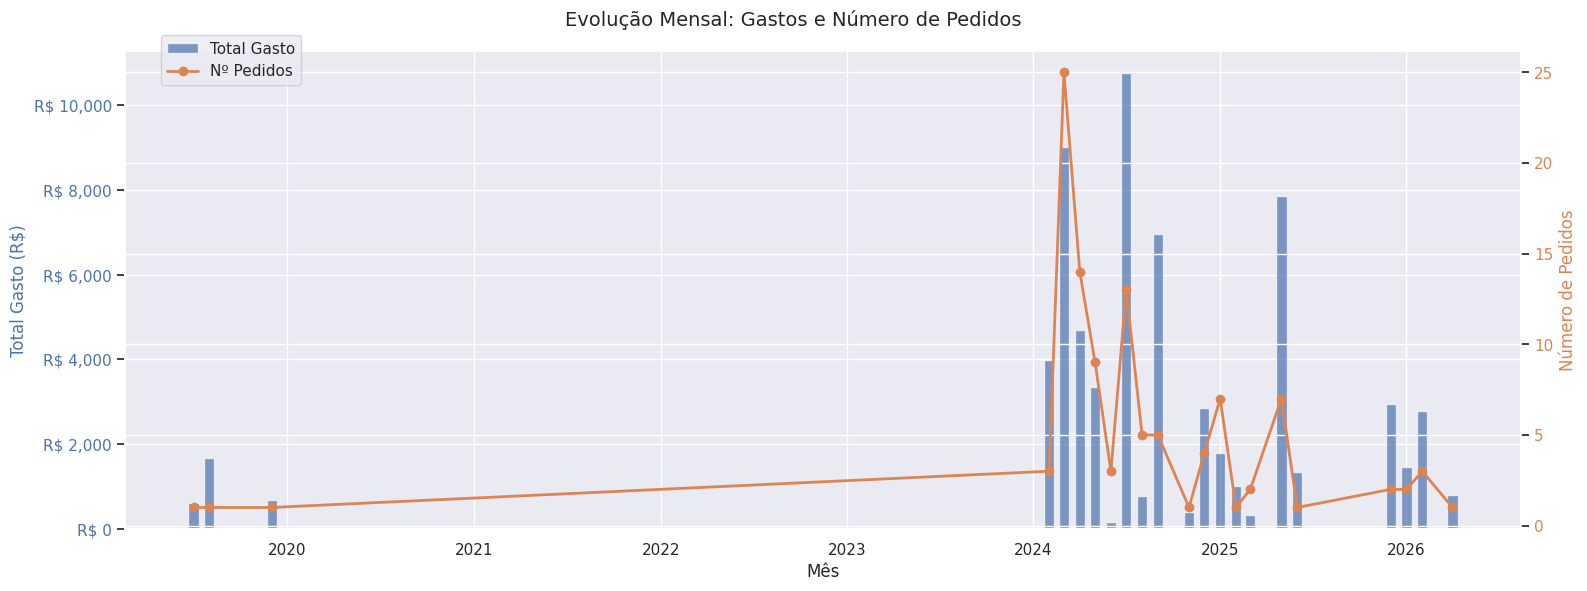

In [9]:
df_dated = df.dropna(subset=["data"]).copy()
df_dated["mes"] = df_dated["data"].dt.to_period("M")

monthly = df_dated.groupby("mes").agg(
    total=("valor", "sum"),
    pedidos=("valor", "count"),
).reset_index()
monthly["mes_dt"] = monthly["mes"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))

color_bar = "#4C72B0"
color_line = "#DD8452"

ax1.bar(monthly["mes_dt"], monthly["total"], width=20, color=color_bar, alpha=0.7, label="Total Gasto")
ax1.set_xlabel("Mês")
ax1.set_ylabel("Total Gasto (R$)", color=color_bar)
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(monthly["mes_dt"], monthly["pedidos"], color=color_line, marker="o", linewidth=2, label="Nº Pedidos")
ax2.set_ylabel("Número de Pedidos", color=color_line)
ax2.tick_params(axis='y', labelcolor=color_line)

fig.suptitle("Evolução Mensal: Gastos e Número de Pedidos", fontsize=14)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Concentração de Gastos (Pareto)

Lojas responsáveis por 80% dos gastos: 10 de 27

Loja                                  Total       %  % Acum
------------------------------------------------------------
SpellCast                      R$  8,845.73   13.3%   13.3%
Monster Games Cards            R$  8,424.73   12.7%   26.0%
UGCardShop                     R$  6,845.15   10.3%   36.4%
Barão Geek House               R$  6,054.13    9.1%   45.5%
Loja do Toguro                 R$  5,948.51    9.0%   54.4%
Prime MTG                      R$  3,919.10    5.9%   60.4%
Gold House                     R$  3,827.04    5.8%   66.1%
MMGeekGames                    R$  3,542.54    5.3%   71.5%
City Class Games               R$  2,720.33    4.1%   75.6%
XPlace                         R$  2,321.30    3.5%   79.1%
Magicdomain                    R$  2,170.23    3.3%   82.3%
Meruru                         R$  1,849.38    2.8%   85.1%
MTG Brasil                     R$  1,526.31    2.3%   87.4%
Epic Game                      R$  1,379.60    2.1

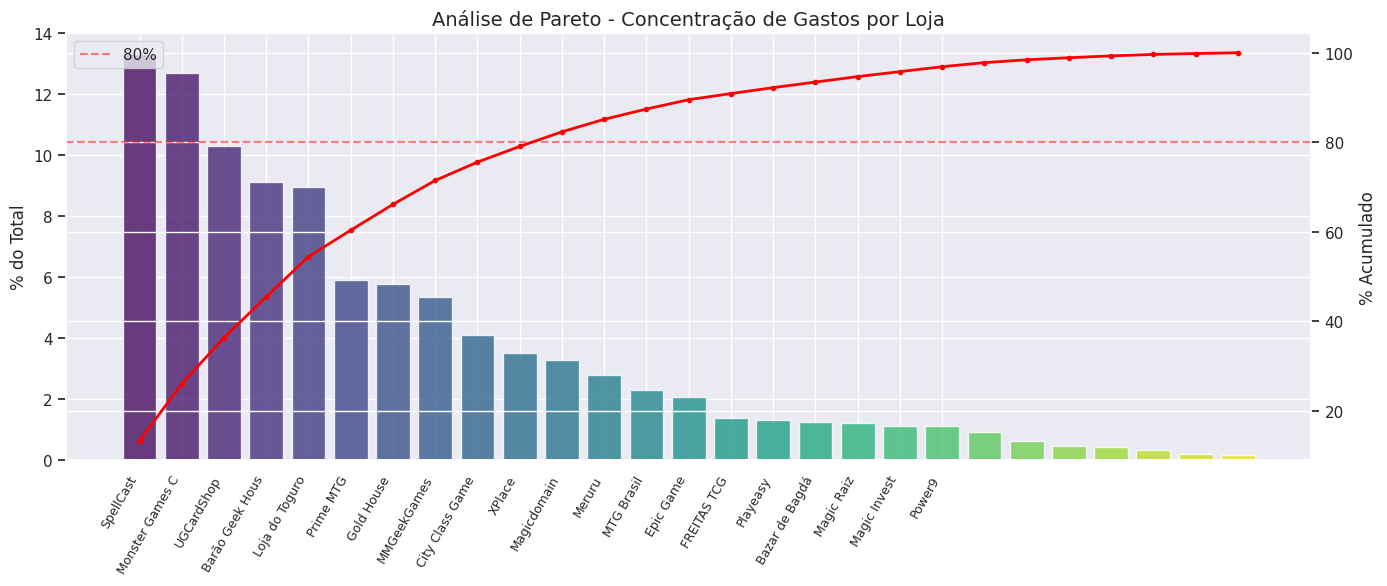

In [10]:
pareto = store_stats[["total_gasto"]].copy()
pareto["pct"] = pareto["total_gasto"] / pareto["total_gasto"].sum() * 100
pareto["pct_acum"] = pareto["pct"].cumsum()

top_80 = pareto[pareto["pct_acum"] <= 80]
print(f"Lojas responsáveis por 80% dos gastos: {len(top_80)} de {len(pareto)}")
print(f"\n{'Loja':<30} {'Total':>12} {'%':>7} {'% Acum':>7}")
print("-" * 60)
for loja, row in pareto.head(20).iterrows():
    print(f"{loja:<30} R$ {row['total_gasto']:>9,.2f} {row['pct']:>6.1f}% {row['pct_acum']:>6.1f}%")

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(pareto))
ax.bar(x, pareto["pct"].values, color=sns.color_palette("viridis", len(pareto)), alpha=0.8)
ax2 = ax.twinx()
ax2.plot(x, pareto["pct_acum"].values, color="red", marker=".", linewidth=2)
ax2.axhline(y=80, color="red", linestyle="--", alpha=0.5, label="80%")
ax2.set_ylabel("% Acumulado")
ax.set_ylabel("% do Total")
ax.set_title("Análise de Pareto - Concentração de Gastos por Loja")
ax.set_xticks(x[:20])
ax.set_xticklabels([s[:15] for s in pareto.index[:20]], rotation=60, ha="right", fontsize=9)
ax2.legend()
plt.tight_layout()
plt.show()


## 9. Distribuição de Status (todos os pedidos)

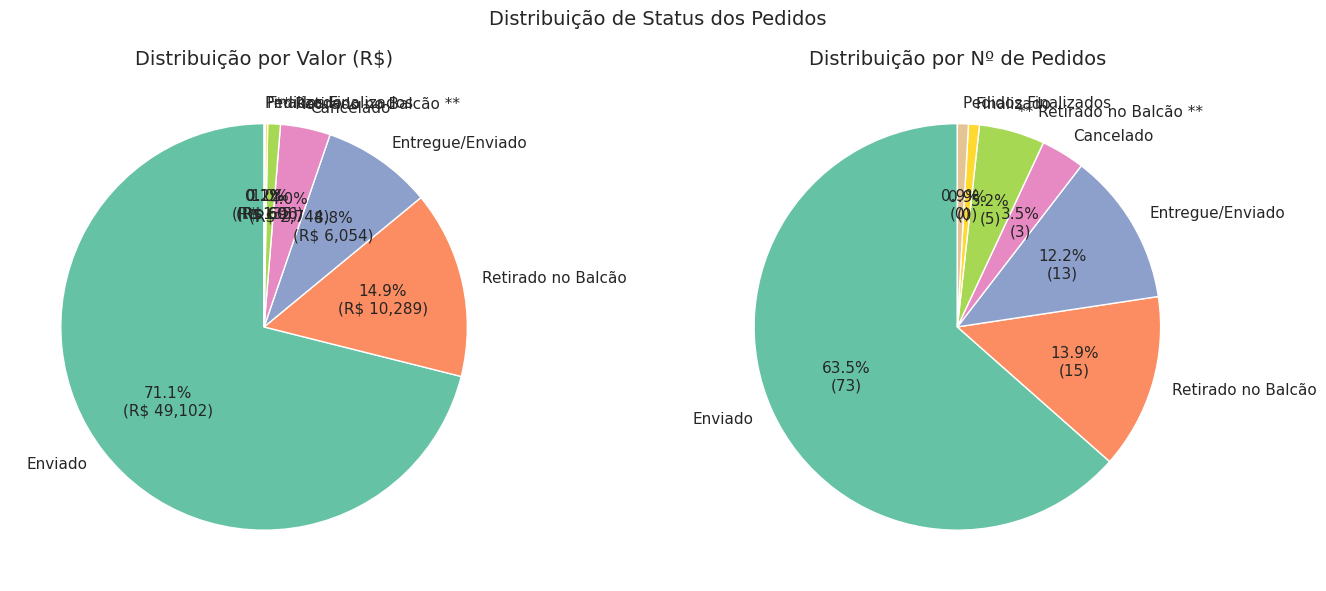

,total,pedidos
status,,
Enviado,49102.20,73
Retirado no Balcão,10289.18,16
Entregue/Enviado,6054.13,14
Cancelado,2743.69,4
** Retirado no Balcão **,696.28,6
Finalizado,134.84,1
Pedidos Finalizados,59.71,1


In [11]:
status_stats = df_all.groupby("status").agg(
    total=("valor", "sum"),
    pedidos=("valor", "count"),
).sort_values("total", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie by value
axes[0].pie(
    status_stats["total"],
    labels=status_stats.index,
    autopct=lambda pct: f"{pct:.1f}%\n(R$ {pct/100 * status_stats['total'].sum():,.0f})",
    colors=sns.color_palette("Set2", len(status_stats)),
    startangle=90,
)
axes[0].set_title("Distribuição por Valor (R$)")

# Pie by count
axes[1].pie(
    status_stats["pedidos"],
    labels=status_stats.index,
    autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100 * status_stats['pedidos'].sum())})",
    colors=sns.color_palette("Set2", len(status_stats)),
    startangle=90,
)
axes[1].set_title("Distribuição por Nº de Pedidos")

fig.suptitle("Distribuição de Status dos Pedidos", fontsize=14)
plt.tight_layout()
plt.show()

status_stats


## 10. Resumo Final

In [12]:
print("=" * 60)
print("           RESUMO DA ANÁLISE DE COMPRAS")
print("=" * 60)
print(f"Total de pedidos (incluindo cancelados):  {len(df_all)}")
print(f"Total de pedidos efetivos:                {len(df)}")
print(f"Total de lojas diferentes:                {df['loja'].nunique()}")
print(f"Total gasto efetivo:                      R$ {df['valor'].sum():,.2f}")
print(f"Total cancelado:                          R$ {df_all[df_all['status'] == 'Cancelado']['valor'].sum():,.2f}")
print(f"Ticket médio por pedido:                  R$ {df['valor'].mean():,.2f}")
print(f"Maior pedido individual:                  R$ {df['valor'].max():,.2f}")
print(f"Menor pedido individual:                  R$ {df['valor'].min():,.2f}")

if df_dated.shape[0] > 0:
    print(f"Período:                                  {df_dated['data'].min().strftime('%d/%m/%Y')} a {df_dated['data'].max().strftime('%d/%m/%Y')}")

print(f"\n🏆 Top 5 lojas por gasto:")
for i, (loja, row) in enumerate(store_stats.head(5).iterrows(), 1):
    print(f"   {i}. {loja}: R$ {row['total_gasto']:,.2f} ({int(row['num_pedidos'])} pedidos)")
print("=" * 60)


           RESUMO DA ANÁLISE DE COMPRAS
Total de pedidos (incluindo cancelados):  115
Total de pedidos efetivos:                111
Total de lojas diferentes:                27
Total gasto efetivo:                      R$ 66,336.34
Total cancelado:                          R$ 2,743.69
Ticket médio por pedido:                  R$ 597.62
Maior pedido individual:                  R$ 3,542.54
Menor pedido individual:                  R$ 9.65
Período:                                  01/07/2019 a 11/04/2026

🏆 Top 5 lojas por gasto:
   1. SpellCast: R$ 8,845.73 (4 pedidos)
   2. Monster Games Cards: R$ 8,424.73 (9 pedidos)
   3. UGCardShop: R$ 6,845.15 (7 pedidos)
   4. Barão Geek House: R$ 6,054.13 (14 pedidos)
   5. Loja do Toguro: R$ 5,948.51 (9 pedidos)
